# 기공 유사사례 매칭 — case DB 구축 & 검색

**목적**: 새 RT 이미지가 들어왔을 때, 과거 사례 중 형태·분포·크기가 비슷한 것을
찾아 "5건 중 4건이 실제 기공이었다" 같은 위험도와 근거를 제시한다.
파이프라인 ⑤ "유사사례 매칭 + 위험도 산출" 단계 구현.

**이 노트북은 `porosity_yolov8seg.ipynb`(학습)와 별도로 관리한다.**
- 학습 노트북: YOLO 모델을 만드는 것 (한 번 하면 끝, 무거움, GPU 필요)
- 이 노트북: 그 모델의 출력을 소비해서 유사사례를 찾는 것 (자주 다시 돌아갈 수 있음)
- `case_features.py` / `similarity.py` / `case_db_build.py`는 **ultralytics(torch) 없이도
  동작** — 새 이미지를 실제 검출할 때만 학습된 `best.pt`가 필요하다.

## 핵심 아이디어

1. `annotation_case`(기공/정상) 라벨을 그대로 "실제 판정"으로 취급해 **초기 case DB**를 만든다.
   나중에 현장 판정 이력(파이프라인 ⑨)이 쌓이면 이 DB를 교체/보강하면 된다.
2. 새 이미지 → YOLO 검출 → 형태/분포/크기 프로파일 추출 → case DB에서 유사 top-k 검색
   → "위험도 + 왜 비슷한지" 요약 보고서 생성.


## 0. 환경 설정

학습 노트북과 동일한 경로 탐색 로직을 재사용한다.

In [1]:
import os, sys, json, warnings
from pathlib import Path

# --- 경로: 학습 노트북과 동일하게 맞춘다 ---
os.environ["WELDSCAN_ROOT"] = r"C:\Users\user\weldscan\weld_db"
os.environ["WELDSCAN_WORK"] = r"C:\Users\user\weldscan\work"

def _find_src(start: Path) -> Path:
    for base in [start, *start.parents]:
        cand = base / "src"
        if (cand / "porosity" / "__init__.py").exists():
            return cand
    raise FileNotFoundError(
        "src/porosity 를 찾을 수 없습니다.\n"
        f"  탐색 시작 위치: {start}\n"
        "  weldscan_porosity/ 폴더 전체(구조: src/porosity/, notebooks/)를 "
        "함께 받았는지, 이 노트북이 그 안의 notebooks/ 폴더에 있는지 확인하세요.\n"
        "  case_features.py / similarity.py / case_db_build.py 세 파일이 "
        "src/porosity/ 안에 있는지도 확인하세요."
    )

SRC = _find_src(Path.cwd())
sys.path.insert(0, str(SRC.resolve()))
print("src 경로 확인:", SRC.resolve())

%load_ext autoreload
%autoreload 2

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import porosity
from porosity import config as cfg, data_prep as D, label_io as L
from porosity import case_features as CF, similarity as S, case_db_build as CDB

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)
warnings.filterwarnings("ignore", category=UserWarning)

cfg.PATHS.ensure()
print("porosity", porosity.__version__, "| schema", cfg.SCHEMA_VERSION)
print("raw :", cfg.PATHS.raw_root, "->", cfg.PATHS.raw_root.exists())
print("work:", cfg.PATHS.work_root)

# 이 노트북은 torch/ultralytics 없이도 case DB 구축·검색이 가능하다.
# 마지막 "실제 검출과 연결" 섹션에서만 학습된 모델이 필요하다.

src 경로 확인: C:\Users\user\weldscan\weldscan_porosity\src
porosity 1.0.0 | schema 1.0
raw : C:\Users\user\weldscan\weld_db -> True
work: C:\Users\user\weldscan\work


In [2]:
df = D.load_metadata()
print(df.shape)
print(df["annotation_case"].value_counts())

(54053, 17)
annotation_case
porosity                                  24209
normal                                    23696
lack of fusion                             2918
crack                                      2053
slag inclusion                             1026
porosity,lack of fusion                      61
porosity,slag inclusion                      29
lack of fusion,porosity                      27
porosity,crack                               26
porosity,slag inclusion,lack of fusion        2
porosity,crack,lack of fusion                 2
normal,porosity                               1
porosity,crack,slag inclusion                 1
porosity,incomplete penetration               1
lack of fusion,porosity,slag inclusion        1
Name: count, dtype: int64


## 1. 픽셀-mm 환산 계수(pixel_spacing_mm)에 대해

`equivalent_diameter_mm`을 정확히 쓰려면 RT 필름의 픽셀당 실제 mm 값이 필요하다.
**현재 메타데이터에는 이 값이 없어** 아래에서는 임시로 `0.1`을 쓴다.

실제 값이 확인되면 `PIXEL_SPACING_MM` 한 곳만 바꾸면 이 노트북 전체에 반영된다.
값이 틀려도 형태/분포 분류에는 영향 없다 - **크기(소/중/대) 판정에만** 영향을 준다.

In [3]:
PIXEL_SPACING_MM = 0.1  # TODO: 실제 값 확인되면 교체

## 2. case DB 소규모 시험 빌드

전체(기공 24,000+장)를 바로 돌리면 몇 분 걸릴 수 있으니, 먼저 일부만 빌드해서
파이프라인이 정상 동작하는지, 크기 임계값이 상식적인 범위인지 확인한다.

In [4]:
QUICK_BUILD = True  # 확인 끝나면 False로 바꿔서 전체 빌드

if QUICK_BUILD:
    profiles, size_thresholds = CDB.build_case_database(
        df, cfg.PATHS, pixel_spacing_mm=PIXEL_SPACING_MM,
        max_positive=3000, max_normal=500,
    )
else:
    profiles, size_thresholds = CDB.build_case_database(
        df, cfg.PATHS, pixel_spacing_mm=PIXEL_SPACING_MM,
    )

print("\n크기 임계값(mm):", size_thresholds)

기공 라벨 파싱:   0%|          | 0/3000 [00:00<?, ?it/s]

파싱 완료: 기공 3000건 (폴리곤 없어 제외 0건)
크기 임계값(diameter 33/67백분위, equivalent_diameter_mm 기준): 소<3.176  중<5.186  대


정상 사례 등록:   0%|          | 0/500 [00:00<?, ?it/s]

case DB 구축 완료: 이상 3000건 + 정상 500건 = 총 3500건

크기 임계값(mm): (3.175549117593941, 5.185650866293716)


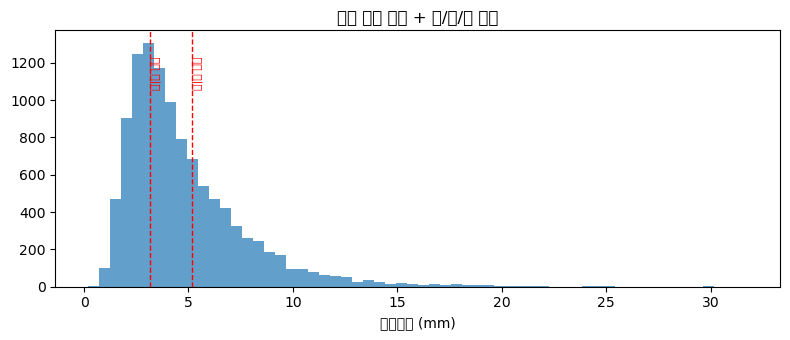

등가직경 범위: 0.20 ~ 31.75 mm  (중앙값 4.04)


In [5]:
# --- 등가직경 분포 + 임계값 위치를 눈으로 확인 ---
all_diam = [d for p in profiles for d in p.diameters]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(all_diam, bins=60, alpha=.7)
for x, lbl in zip(size_thresholds, ["소|중 경계", "중|대 경계"]):
    ax.axvline(x, color="r", ls="--", lw=1)
    ax.text(x, ax.get_ylim()[1]*0.9, lbl, rotation=90, va="top", fontsize=8, color="r")
ax.set_xlabel("등가직경 (mm)"); ax.set_title("기공 크기 분포 + 소/중/대 경계")
plt.tight_layout(); plt.show()

print(f"등가직경 범위: {min(all_diam):.2f} ~ {max(all_diam):.2f} mm  "
      f"(중앙값 {np.median(all_diam):.2f})")

In [6]:
# --- 분포(단독/산재/군집/선상) 및 판정별 통계 확인 ---
stat_df = pd.DataFrame([{
    "verdict": p.verdict, "distribution": p.distribution,
    "n_instances": p.n_instances, "elongated_ratio": p.shape_elongated_ratio,
} for p in profiles])

print("=== verdict x distribution 교차표 ===")
display(pd.crosstab(stat_df["verdict"], stat_df["distribution"]))

print("\n=== 기공 개수(n_instances) 분포 (abnormal만) ===")
display(stat_df[stat_df.verdict == "abnormal"]["n_instances"].describe())

=== verdict x distribution 교차표 ===


distribution,군집,단독,산재,선상,해당없음
verdict,,,,,
abnormal,41,902,1817,240,0
normal,0,0,0,0,500



=== 기공 개수(n_instances) 분포 (abnormal만) ===


count    3000.000000
mean        3.658333
std         3.710461
min         1.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        36.000000
Name: n_instances, dtype: float64

**확인할 것**:
- 크기 임계값(`소|중 경계`, `중|대 경계`)이 상식적인 mm 범위인가? (RT 기공은 보통 0.5~5mm 수준)
- `단독`이 압도적으로 많고 `선상`이 극히 드물게 나오는가? (기공은 대체로 흩어져 있고,
  일렬로 늘어선 건 특이 케이스라 실제로도 드물어야 정상)

이상 없으면 아래에서 `QUICK_BUILD = False`로 바꿔 전체 데이터로 재빌드한다.

In [7]:
# 전체 재빌드 (QUICK_BUILD 검증 후 실행) - 기공 24,000+장 파싱, 수 분 소요 가능
QUICK_BUILD = False

if not QUICK_BUILD:
    profiles, size_thresholds = CDB.build_case_database(
        df, cfg.PATHS, pixel_spacing_mm=PIXEL_SPACING_MM,
    )
    print("\n전체 재빌드 완료. 크기 임계값(mm):", size_thresholds)

기공 라벨 파싱:   0%|          | 0/24209 [00:00<?, ?it/s]

파싱 완료: 기공 24209건 (폴리곤 없어 제외 0건)
크기 임계값(diameter 33/67백분위, equivalent_diameter_mm 기준): 소<3.192  중<5.239  대


정상 사례 등록:   0%|          | 0/2090 [00:00<?, ?it/s]

case DB 구축 완료: 이상 24209건 + 정상 2090건 = 총 26299건

전체 재빌드 완료. 크기 임계값(mm): (3.1915358425578386, 5.238773392313827)


## 3. case DB 저장

대시보드/유사사례 검색 API가 이 폴더 경로만 알면 된다.

In [8]:
case_db_dir = cfg.PATHS.work_root / "case_db"
S.save_case_db(profiles, size_thresholds, case_db_dir)
print("저장 위치:", case_db_dir)
print(*[p.name for p in sorted(case_db_dir.iterdir())], sep="\n")

case_db_df, size_thresholds = S.load_case_db(case_db_dir)
print("\n재로딩 확인: 총", len(case_db_df), "건")

저장 위치: C:\Users\user\weldscan\work\case_db
case_db.parquet
size_thresholds.json

재로딩 확인: 총 26299 건


In [9]:
case_db_dir = cfg.PATHS.work_root / "case_db"
case_db_df, size_thresholds = S.load_case_db(case_db_dir)
print("재로딩 확인: 총", len(case_db_df), "건")

재로딩 확인: 총 26299 건


## 4. 실제 검출 결과와 연결 (학습된 모델 필요)

여기서부터 `porosity_yolov8seg.ipynb`에서 만든 `best.pt`가 필요하다.
같은 handoff 파일(`last_train_run_demo.json`)에서 경로를 불러온다.

In [10]:
import os as _os
_os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # Windows OMP 충돌 우회

info = json.loads((cfg.PATHS.work_root / "last_train_run_demo.json").read_text(encoding="utf-8"))
best_pt = Path(info["best_pt"])
print("모델:", best_pt, "->", best_pt.exists())

from porosity.detector import PorosityDetector
det = PorosityDetector.from_artifacts(cfg.PATHS.artifacts_dir, device=cfg.TRAIN.device)
print("디텍터 로드 완료")

모델: C:\Users\user\weldscan\work\runs\porosity_seg_demo\weights\best.pt -> True
디텍터 로드 완료


In [11]:
# --- 검증용: case DB에 이미 들어있는 기공 이미지 하나로 실제 검출 -> 유사사례 검색까지 ---
sample_row = df[df["annotation_case"] == "porosity"].iloc[10]
sample_img = cfg.PATHS.raw_root / sample_row.image_path

out = det.predict(sample_img, pixel_spacing_mm=PIXEL_SPACING_MM)
print(f"검출 결과: verdict={out['verdict']}  n_instances={out['n_instances']}  "
      f"score={out['score']:.3f}")

profile = CF.build_case_profile(
    out["instances"], out["image"]["width"], out["image"]["height"],
    size_thresholds,
)
print(f"프로필: 분포={profile.distribution}  길쭉비율={profile.shape_elongated_ratio:.2f}  "
      f"크기분포={profile.size_hist}")

검출 결과: verdict=abnormal  n_instances=4  score=0.534
프로필: 분포=산재  길쭉비율=0.25  크기분포={'소': 0.25, '중': 0.75, '대': 0.0}


In [14]:
matches = S.find_similar_cases_diverse(profile, case_db_df, k=5)
report = S.generate_report(profile, matches)

print("=== 보고서 ===")
print(report["summary_text"])
print()
print(f"위험도: {report['risk_level']}  "
      f"(유사사례 {report['n_similar']}건 중 {report['n_abnormal_in_similar']}건 이상)")
print("축별 평균 유사도:", report["avg_similarity_breakdown"])
print()
print("=== 유사사례 top5 ===")
for m in report["matches"]:
    print(f"  score={m['score']:.4f}  분포={m['distribution']:6s}  "
          f"verdict={m['verdict']:8s}  {m['meta'].get('stem')}")

=== 보고서 ===
유사 사례 5건 중 5건이 실제로 기공 결함이 있었습니다 (위험도: 높음). 가장 비슷했던 특징은 기공 형태입니다. 이번 사진은 기공 4개, 배치는 '산재', 크기는 대부분 '중' 입니다.

위험도: 높음  (유사사례 5건 중 5건 이상)
축별 평균 유사도: {'distribution': 0.995, 'shape': 1.0, 'size': 0.9}

=== 유사사례 top5 ===
  score=0.9970  분포=산재      verdict=abnormal  RT_ST_02_14547983
  score=0.9940  분포=산재      verdict=abnormal  RT_ST_02_14522993
  score=0.9870  분포=산재      verdict=abnormal  RT_ST_02_14521656
  score=0.9590  분포=산재      verdict=abnormal  RT_ST_02_14533652
  score=0.9590  분포=산재      verdict=abnormal  RT_ST_02_14522282


In [15]:
sample_stats = case_db_df.iloc[0]["distribution_stats"]
print(sample_stats)
print("mean_nn_norm 포함됨?", "mean_nn_norm" in sample_stats)

{"n": 1}
mean_nn_norm 포함됨? False


In [16]:
multi = case_db_df[case_db_df["n_instances"] >= 4].iloc[0]
print(multi["distribution_stats"])
print("mean_nn_norm 포함됨?", "mean_nn_norm" in multi["distribution_stats"])

{"n": 6, "extent_ratio": 0.7308, "mean_nn_norm": 0.1973, "spread_ratio": 0.5417, "linear_ratio": null}
mean_nn_norm 포함됨? True


In [13]:
print("=== fine_tiebreak 세부 구성 확인 ===")
for m in matches:   # report["matches"]가 아니라 matches
    p2 = m["profile"]
    from porosity.similarity import continuous_tiebreak, _safe_mean
    n1, n2 = profile.n_instances, p2.n_instances
    d1, d2 = _safe_mean(profile.diameters), _safe_mean(p2.diameters)
    e1 = (profile.distribution_stats or {}).get("extent_ratio")
    e2 = (p2.distribution_stats or {}).get("extent_ratio")
    print(f"  {p2.meta.get('stem'):20s} n=({n1},{n2}) mean_d=({d1:.3f},{d2:.3f}) "
          f"extent=({e1},{e2})  raw_score={m['score']:.6f}")

=== fine_tiebreak 세부 구성 확인 ===
  RT_ST_02_14547983    n=(4,4) mean_d=(3.880,3.729) extent=(0.4753,0.4688)  raw_score=0.996810
  RT_ST_02_14530560    n=(4,4) mean_d=(3.880,3.538) extent=(0.4753,0.4735)  raw_score=0.996609
  RT_ST_02_14524682    n=(4,4) mean_d=(3.880,3.532) extent=(0.4753,0.4689)  raw_score=0.995584
  RT_ST_02_14522993    n=(4,4) mean_d=(3.880,3.269) extent=(0.4753,0.4777)  raw_score=0.994292
  RT_ST_02_14521403    n=(4,4) mean_d=(3.880,3.930) extent=(0.4753,0.4491)  raw_score=0.993018


## 5. 유사사례 시각 비교 — 텍스트만 믿지 말고 눈으로 확인

숫자로는 그럴듯해도, 실제 이미지를 나란히 봤을 때 정말 비슷한지 확인하는 게
"초보 검사자가 이해하기 쉬운 보고서"의 핵심이다.

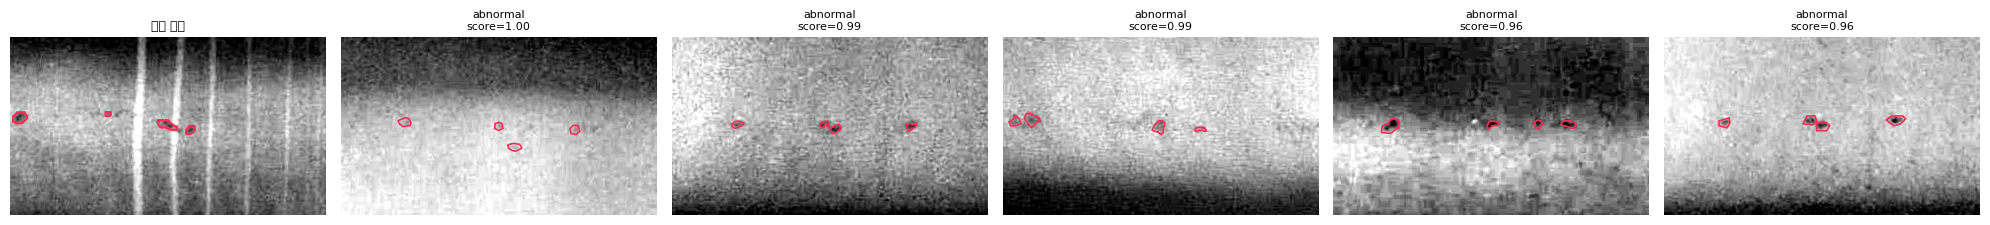

In [18]:
from PIL import Image, ImageOps
from matplotlib.patches import Polygon as MplPoly

def show_with_contrast(ax, img_path):
    im = Image.open(img_path).convert("L")
    im = ImageOps.autocontrast(im, cutoff=1)  # 시각화 전용 - 모델 입력/판정엔 영향 없음
    ax.imshow(im, cmap="gray")

fig, axes = plt.subplots(1, 6, figsize=(20, 4))

show_with_contrast(axes[0], sample_img)
for ins in out["instances"]:
    axes[0].add_patch(MplPoly(ins["polygon_xy"], closed=True, fill=False,
                              ec="#ff2d55", lw=1.5))
axes[0].set_title("신규 사진", fontsize=9)
axes[0].axis("off")

for ax, m in zip(axes[1:], report["matches"]):
    meta = m["meta"]
    img_path = cfg.PATHS.raw_root / meta["image_path"]
    if img_path.exists():
        show_with_contrast(ax, img_path)
        # GT 폴리곤 오버레이 - label_id로 원본 라벨 위치 조회
        row = df[df["label_id"] == meta["label_id"]]
        if len(row):
            label_path = cfg.PATHS.raw_root / row.iloc[0]["label_path"]
            w, h = int(row.iloc[0]["width"]), int(row.iloc[0]["height"])
            polys, _ = L.extract_porosity_polygons(label_path, w, h)
            for poly in polys:
                pts = np.array(poly).reshape(-1, 2) * [w, h]
                ax.add_patch(MplPoly(pts, closed=True, fill=False,
                                     ec="#ff2d55", lw=1.2))
    ax.set_title(f"{m['verdict']}\nscore={m['score']:.2f}", fontsize=8)
    ax.axis("off")

plt.tight_layout(); plt.show()

## 6. 계약 스키마 확인 (대시보드 연동용)

`generate_report()`의 출력 구조가 고정 스키마를 지키는지 확인한다.
이 키들이 깨지면 대시보드가 깨진다 - 학습 노트북의 8번 섹션과 동일한 원칙.

In [19]:
REQUIRED = {"risk_level", "n_similar", "n_abnormal_in_similar",
            "summary_text", "avg_similarity_breakdown", "matches"}
assert REQUIRED <= set(report), f"스키마 누락: {REQUIRED - set(report)}"
assert report["risk_level"] in {"높음", "보통", "낮음", "해당없음"}
json.dumps(report)   # JSON 직렬화 가능해야 API로 나갈 수 있다
print("유사사례 보고서 스키마 OK")

유사사례 보고서 스키마 OK


## 정리

| 산출물 | 위치 |
|---|---|
| case DB | `work/case_db/` (`case_db.parquet` + `size_thresholds.json`) |
| 사용 모듈 | `porosity.case_features`, `porosity.similarity`, `porosity.case_db_build` |

### 대시보드/API 쪽에 전달할 사용법

```python
from porosity import case_features as CF, similarity as S

case_db, size_th = S.load_case_db("work/case_db 경로")

out = det.predict(image_path, pixel_spacing_mm=0.1)  # 기존 YOLO 검출
profile = CF.build_case_profile(out["instances"], out["image"]["width"],
                                out["image"]["height"], size_th)
matches = S.find_similar_cases(profile, case_db, k=5)
report = S.generate_report(profile, matches)

report["summary_text"]      # 초보자용 한 줄 요약
report["risk_level"]        # "높음"/"보통"/"낮음"
report["matches"]           # 유사사례 5건 (사진 경로, 판정, 유사도)
```

### 남은 한계 / 다음에 다듬을 것

1. **`pixel_spacing_mm`이 아직 임시값(0.1)** - 실제 값 확정되면 이 노트북과
   `PorosityDetector` 호출부 전체에서 교체 필요. 크기(소/중/대) 판정에만 영향.
2. **분류 임계값(`case_features.py`의 `SHAPE_ELONGATION_THRESHOLD`,
   `LINEAR_VARIANCE_RATIO_THRESHOLD` 등)은 경험적 기본값** - 실제 데이터의 분포
   확인 후(2번 섹션 결과 참고) 필요하면 조정.
3. **정상 사례는 형태/분포 정보가 없어(인스턴스 0개) 유사도 계산에서 항상
   "다름"으로 처리됨** - 정상끼리의 유사도가 필요해지면 별도 로직이 필요하다.
4. **case DB는 GT 라벨 기반 초기 버전** - 현장 판정 이력이 쌓이면(파이프라인 ⑨)
   `verdict`를 실제 리젝/합격 결과로 교체하는 것을 권장.
